In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import scienceplots
import torch

# ==========================================
# 辅助函数
# ==========================================
def gaussian_pdf(x):
    if isinstance(x, torch.Tensor):
        return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

# def generate_chirp_signal(Nx_total, f_start=0.005, f_end=0.05, amplitude=1.0, seed=42):
#     """
#     生成线性调频信号 (Chirp Signal)
    
#     参数:
#         Nx_total: 信号长度
#         f_start: 起始归一化频率
#         f_end: 结束归一化频率
#         amplitude: 幅度
#         seed: 随机种子###预留加入噪声的
#     """
#     torch.manual_seed(seed)
#     t = torch.arange(Nx_total, dtype=torch.float32)
    
#     # 线性调频
#     chirp_rate = (f_end - f_start) / Nx_total
#     phase = 2 * np.pi * (f_start * t + 0.5 * chirp_rate * t**2)
#     chirp_signal = amplitude * torch.sin(phase)
    
#     return chirp_signal.reshape(-1, 1)
def generate_chirp_signal(Nx_total, f_start=0.005, f_end=0.05, amplitude=1.0):
    """
    生成线性调频信号 (Chirp Signal)
    在后半段时间幅值变为0.8倍
    
    参数:
        Nx_total: 信号长度
        f_start: 起始归一化频率
        f_end: 结束归一化频率
        amplitude: 幅度
        seed: 随机种子###预留加入噪声的
    """
    t = torch.arange(Nx_total, dtype=torch.float32)
    
    # 线性调频
    chirp_rate = (f_end - f_start) / Nx_total
    phase = 2 * np.pi * (f_start * t + 0.5 * chirp_rate * t**2)
    chirp_signal = amplitude * torch.sin(phase + np.pi)
    
    # 在后半段时间将幅值变为0.64倍
    half_point = Nx_total // 2
    chirp_signal[half_point:] *= 0.6
    
    return chirp_signal.reshape(-1, 1)

In [2]:
# ==========================================
# EKF
# ==========================================
def run_chirp_tracking(input_signal, init_sigma, N1=15, N2=16, theta1=-0.45, theta2=0.55, 
                       seed_val=42, window_size=50):
    """
    使用双组阈值阵列跟踪Chirp信号
    参数分别是输入信号，初始sigma值，分组情况，分组阈值，噪声种子，滑动窗大小
    """
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    
    Nx_total = input_signal.shape[0]
    
    # --- 初始化权系数向量和协方差 ---
    W_vec = torch.tensor([[1.0], [1.0]], dtype=torch.float32)
    P_rls = torch.eye(2) * 10.0
    
    # --- EKF 初始化 ---
    sigma_curr = init_sigma
    P_sigma = 2.0
    Q_sigma = 1e-4
    R_sigma = 1.0
    
    # --- 记录数组 ---
    sigma_history = torch.zeros(Nx_total)
    W1_history = torch.zeros(Nx_total)
    W2_history = torch.zeros(Nx_total)
    H_k_history = torch.zeros(Nx_total)
    
    # 核心指标
    instantaneous_error = torch.zeros(Nx_total)  # 瞬时误差 e_k
    instantaneous_mse = torch.zeros(Nx_total)    # e_k^2
    windowed_mse = torch.zeros(Nx_total) ##50的滑动窗
    
    #参数变化率
    sigma_rate = torch.zeros(Nx_total)  # dσ/dk
    W1_rate = torch.zeros(Nx_total)     # dw1/dk
    W2_rate = torch.zeros(Nx_total)     # dw2/dk
    
    # 预测输出
    y_hat_history = torch.zeros(Nx_total)
    
    for k in range(Nx_total):
        x_k = input_signal[k, 0]
        
        # 1. 生成观测
        torch.manual_seed(seed_val + k * 100)
        noise_std = max(sigma_curr, 0.01)
        
        # Group 1
        noise1 = noise_std * torch.randn(N1, 1)
        y1_vec = torch.sign(x_k + noise1 - theta1)
        phi1 = torch.mean(y1_vec)
        # Group 2
        torch.manual_seed(seed_val + k * 200)
        noise2 = noise_std * torch.randn(N2, 1)
        y2_vec = torch.sign(x_k + noise2 - theta2)
        phi2 = torch.mean(y2_vec)
        
        phi_vec = torch.tensor([[phi1], [phi2]])
        
        # 2. Vector RLS 更新
        y_hat = torch.matmul(W_vec.T, phi_vec)
        e_k = x_k - y_hat
        
        numer = torch.matmul(P_rls, phi_vec)
        denom = torch.matmul(phi_vec.T, torch.matmul(P_rls, phi_vec)) + 0.1
        g_rls = numer / denom
        
        W_vec_old = W_vec.clone()
        W_vec = W_vec + g_rls * e_k
        P_rls = P_rls - torch.matmul(g_rls, torch.matmul(phi_vec.T, P_rls))
        
        # 3. EKF 预测
        sigma_pred = sigma_curr
        P_pred = P_sigma + Q_sigma
        
        # 4. 计算 Jacobian H_k
        s_safe = max(sigma_pred, 0.01)
        
        u1 = (x_k - theta1) / s_safe
        pdf1 = gaussian_pdf(u1)
        h1 = -2.0 * W_vec[0].item() * ((x_k - theta1) / s_safe**2) * pdf1
        
        u2 = (x_k - theta2) / s_safe
        pdf2 = gaussian_pdf(u2)
        h2 = -2.0 * W_vec[1].item() * ((x_k - theta2) / s_safe**2) * pdf2
        
        H_k = h1 + h2
        
        # 5. EKF 更新
        S_innov = H_k**2 * P_pred + R_sigma
        K_sigma = P_pred * H_k / S_innov
        
        step = K_sigma * e_k.item()
        step = max(min(step, 0.5), -0.5)
        
        sigma_old = sigma_curr
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)
        P_sigma = (1 - K_sigma * H_k) * P_pred
        
        # 6. 记录数据
        sigma_history[k] = sigma_curr
        W1_history[k] = W_vec[0].item()
        W2_history[k] = W_vec[1].item()
        H_k_history[k] = H_k
        y_hat_history[k] = y_hat.item()
        
        instantaneous_error[k] = e_k.item()
        instantaneous_mse[k] = e_k.item()**2
        
        # 计算变化率 (使用差分近似导数)
        if k > 0:
            sigma_rate[k] = sigma_curr - sigma_old
            W1_rate[k] = W_vec[0].item() - W_vec_old[0].item()
            W2_rate[k] = W_vec[1].item() - W_vec_old[1].item()
        
        # 滑动平均 MSE
        if k < window_size:
            windowed_mse[k] = torch.mean(instantaneous_mse[:k+1]).item()
        else:
            windowed_mse[k] = torch.mean(instantaneous_mse[k-window_size+1:k+1]).item()
            
        sigma_curr = sigma_new
    
    return {
        'sigma_hist': sigma_history.numpy(),
        'W1_hist': W1_history.numpy(),
        'W2_hist': W2_history.numpy(),
        'H_k_hist': H_k_history.numpy(),
        'y_hat_hist': y_hat_history.numpy(),
        'error_hist': instantaneous_error.numpy(),
        'mse_hist': windowed_mse.numpy(),
        'sigma_rate': sigma_rate.numpy(),
        'W1_rate': W1_rate.numpy(),
        'W2_rate': W2_rate.numpy(),
        'input_signal': input_signal.squeeze().numpy()
    }

In [3]:
def compute_tracking_metrics(results, transition_point=1500, steady_window=300):
    """
    计算跟踪性能指标 - 分段版本
    
    参数:
        results: 跟踪结果
        transition_point: 幅值变化点
        steady_window: 稳态统计窗口长度
    """
    Nx_total = len(results['error_hist'])
    
    metrics = {}
    
    # === 分段稳态分析 ===
    # 第一段稳态：变化前
    segment1_start = max(0, transition_point - steady_window - 200)
    segment1_end = transition_point - 50  # 留出过渡区
    
    # 第二段稳态：变化后
    segment2_start = transition_point + 200  # 跳过瞬态响应
    segment2_end = min(Nx_total, transition_point + steady_window + 200)
    
    # 1. σ 的分段稳态值
    metrics['segment1'] = {
        'start': segment1_start,
        'end': segment1_end,
        'sigma_mean': np.mean(results['sigma_hist'][segment1_start:segment1_end]),
        'sigma_std': np.std(results['sigma_hist'][segment1_start:segment1_end]),
        'W1_mean': np.mean(results['W1_hist'][segment1_start:segment1_end]),
        'W2_mean': np.mean(results['W2_hist'][segment1_start:segment1_end]),
        'mse_mean': np.mean(results['mse_hist'][segment1_start:segment1_end])
    }
    
    metrics['segment2'] = {
        'start': segment2_start,
        'end': segment2_end,
        'sigma_mean': np.mean(results['sigma_hist'][segment2_start:segment2_end]),
        'sigma_std': np.std(results['sigma_hist'][segment2_start:segment2_end]),
        'W1_mean': np.mean(results['W1_hist'][segment2_start:segment2_end]),
        'W2_mean': np.mean(results['W2_hist'][segment2_start:segment2_end]),
        'mse_mean': np.mean(results['mse_hist'][segment2_start:segment2_end])
    }
    
    # 2. 参数变化量
    metrics['sigma_change'] = metrics['segment2']['sigma_mean'] - metrics['segment1']['sigma_mean']
    metrics['W1_change'] = metrics['segment2']['W1_mean'] - metrics['segment1']['W1_mean']
    metrics['W2_change'] = metrics['segment2']['W2_mean'] - metrics['segment1']['W2_mean']
    
    # 3. 瞬时跟踪误差包络
    window = 100
    error_envelope = np.zeros(Nx_total)
    for i in range(Nx_total):
        start = max(0, i - window)
        error_envelope[i] = np.std(results['error_hist'][start:i+1])
    metrics['error_envelope'] = error_envelope
    
    # 4. 参数调整速度
    metrics['sigma_rate_rms'] = np.sqrt(np.mean(results['sigma_rate'][100:]**2))
    metrics['W1_rate_rms'] = np.sqrt(np.mean(results['W1_rate'][100:]**2))
    metrics['W2_rate_rms'] = np.sqrt(np.mean(results['W2_rate'][100:]**2))
    
    # 5. 收敛速度（针对第二段）
    steady_mse_seg2 = metrics['segment2']['mse_mean']
    alpha = 1.1
    threshold = alpha * steady_mse_seg2##小于1.1MSE则收敛了
    L_confirm = 50
    
    convergence_time = Nx_total - transition_point  # 默认未收敛
    
    for k in range(transition_point, Nx_total - L_confirm):
        if np.all(results['mse_hist'][k:k+L_confirm] < threshold):
            convergence_time = k - transition_point  # 相对于变化点的时间
            break
    
    metrics['convergence_time_segment2'] = convergence_time
    
    return metrics

In [4]:
# ==========================================
# 主程序：运行跟踪实验
# ==========================================
print("="*80)
print("CHIRP SIGNAL TRACKING WITH DUAL-GROUP STOCHASTIC RESONANCE")
print("="*80)

# 参数设置
Nx_total = 3000
f_start, f_end = 0.005, 0.05
amplitude = 1.0
init_sigma = 1.0
seed_val = 42

# 生成Chirp信号（幅值变为0.64倍）
print(f"\nGenerating Chirp signal...")
print(f"  Length: {Nx_total}")
print(f"  Frequency range: {f_start} → {f_end}")
print(f"  Amplitude: {amplitude}")

chirp_signal = generate_chirp_signal(Nx_total, f_start, f_end, amplitude)

# 幅值改变时刻
half_point = Nx_total // 2

# 运行跟踪
print(f"\nRunning tracking algorithm...")
print(f"  Initial σ: {init_sigma}")

results = run_chirp_tracking(chirp_signal, init_sigma, seed_val=seed_val)

#使用新的评估函数，传入transition_point ***
print(f"\nComputing performance metrics (segmented analysis)...")
transition_point = half_point
metrics = compute_tracking_metrics(results, transition_point=transition_point, steady_window=300)

# 打印评估
print("\n" + "="*80)
print("TRACKING PERFORMANCE METRICS (SEGMENTED ANALYSIS)")
print("="*80)

print(f"\n=== SEGMENT 1 (Before Amplitude Change, k=[{metrics['segment1']['start']}, {metrics['segment1']['end']}]) ===")
print(f"   σ steady-state:  {metrics['segment1']['sigma_mean']:.4f} ± {metrics['segment1']['sigma_std']:.4f}")
print(f"   w1 steady-state: {metrics['segment1']['W1_mean']:.4f}")
print(f"   w2 steady-state: {metrics['segment1']['W2_mean']:.4f}")
print(f"   MSE:             {metrics['segment1']['mse_mean']:.6f}")

print(f"\n=== SEGMENT 2 (After Amplitude Change, k=[{metrics['segment2']['start']}, {metrics['segment2']['end']}]) ===")
print(f"   σ steady-state:  {metrics['segment2']['sigma_mean']:.4f} ± {metrics['segment2']['sigma_std']:.4f}")
print(f"   w1 steady-state: {metrics['segment2']['W1_mean']:.4f}")
print(f"   w2 steady-state: {metrics['segment2']['W2_mean']:.4f}")
print(f"   MSE:             {metrics['segment2']['mse_mean']:.6f}")

print(f"\n=== PARAMETER CHANGES (Segment2 - Segment1) ===")
print(f"   Δσ:  {metrics['sigma_change']:+.4f}  ({metrics['sigma_change']/metrics['segment1']['sigma_mean']*100:+.1f}%)")
print(f"   Δw1: {metrics['W1_change']:+.4f}  ({metrics['W1_change']/metrics['segment1']['W1_mean']*100:+.1f}%)")
print(f"   Δw2: {metrics['W2_change']:+.4f}  ({metrics['W2_change']/metrics['segment1']['W2_mean']*100:+.1f}%)")

print(f"\n=== TRANSIENT RESPONSE ===")
print(f"   Re-convergence time: {metrics['convergence_time_segment2']} samples")

print("\n" + "="*80)

# 保存结果供绘图使用
tracking_results = {
    'results': results,
    'metrics': metrics,
    'signal_params': {
        'Nx_total': Nx_total,
        'f_start': f_start,
        'f_end': f_end,
        'amplitude': amplitude,
        'transition_point': transition_point  # 添加这个
    }
}

print("\nResults saved for plotting.")

CHIRP SIGNAL TRACKING WITH DUAL-GROUP STOCHASTIC RESONANCE

Generating Chirp signal...
  Length: 3000
  Frequency range: 0.005 → 0.05
  Amplitude: 1.0

Running tracking algorithm...
  Initial σ: 1.0

Computing performance metrics (segmented analysis)...

TRACKING PERFORMANCE METRICS (SEGMENTED ANALYSIS)

=== SEGMENT 1 (Before Amplitude Change, k=[1000, 1450]) ===
   σ steady-state:  0.3077 ± 0.0055
   w1 steady-state: 0.5284
   w2 steady-state: 0.4468
   MSE:             0.012467

=== SEGMENT 2 (After Amplitude Change, k=[1700, 2000]) ===
   σ steady-state:  0.3670 ± 0.0122
   w1 steady-state: 0.5262
   w2 steady-state: 0.4459
   MSE:             0.015553

=== PARAMETER CHANGES (Segment2 - Segment1) ===
   Δσ:  +0.0593  (+19.3%)
   Δw1: -0.0022  (-0.4%)
   Δw2: -0.0009  (-0.2%)

=== TRANSIENT RESPONSE ===
   Re-convergence time: 47 samples


Results saved for plotting.


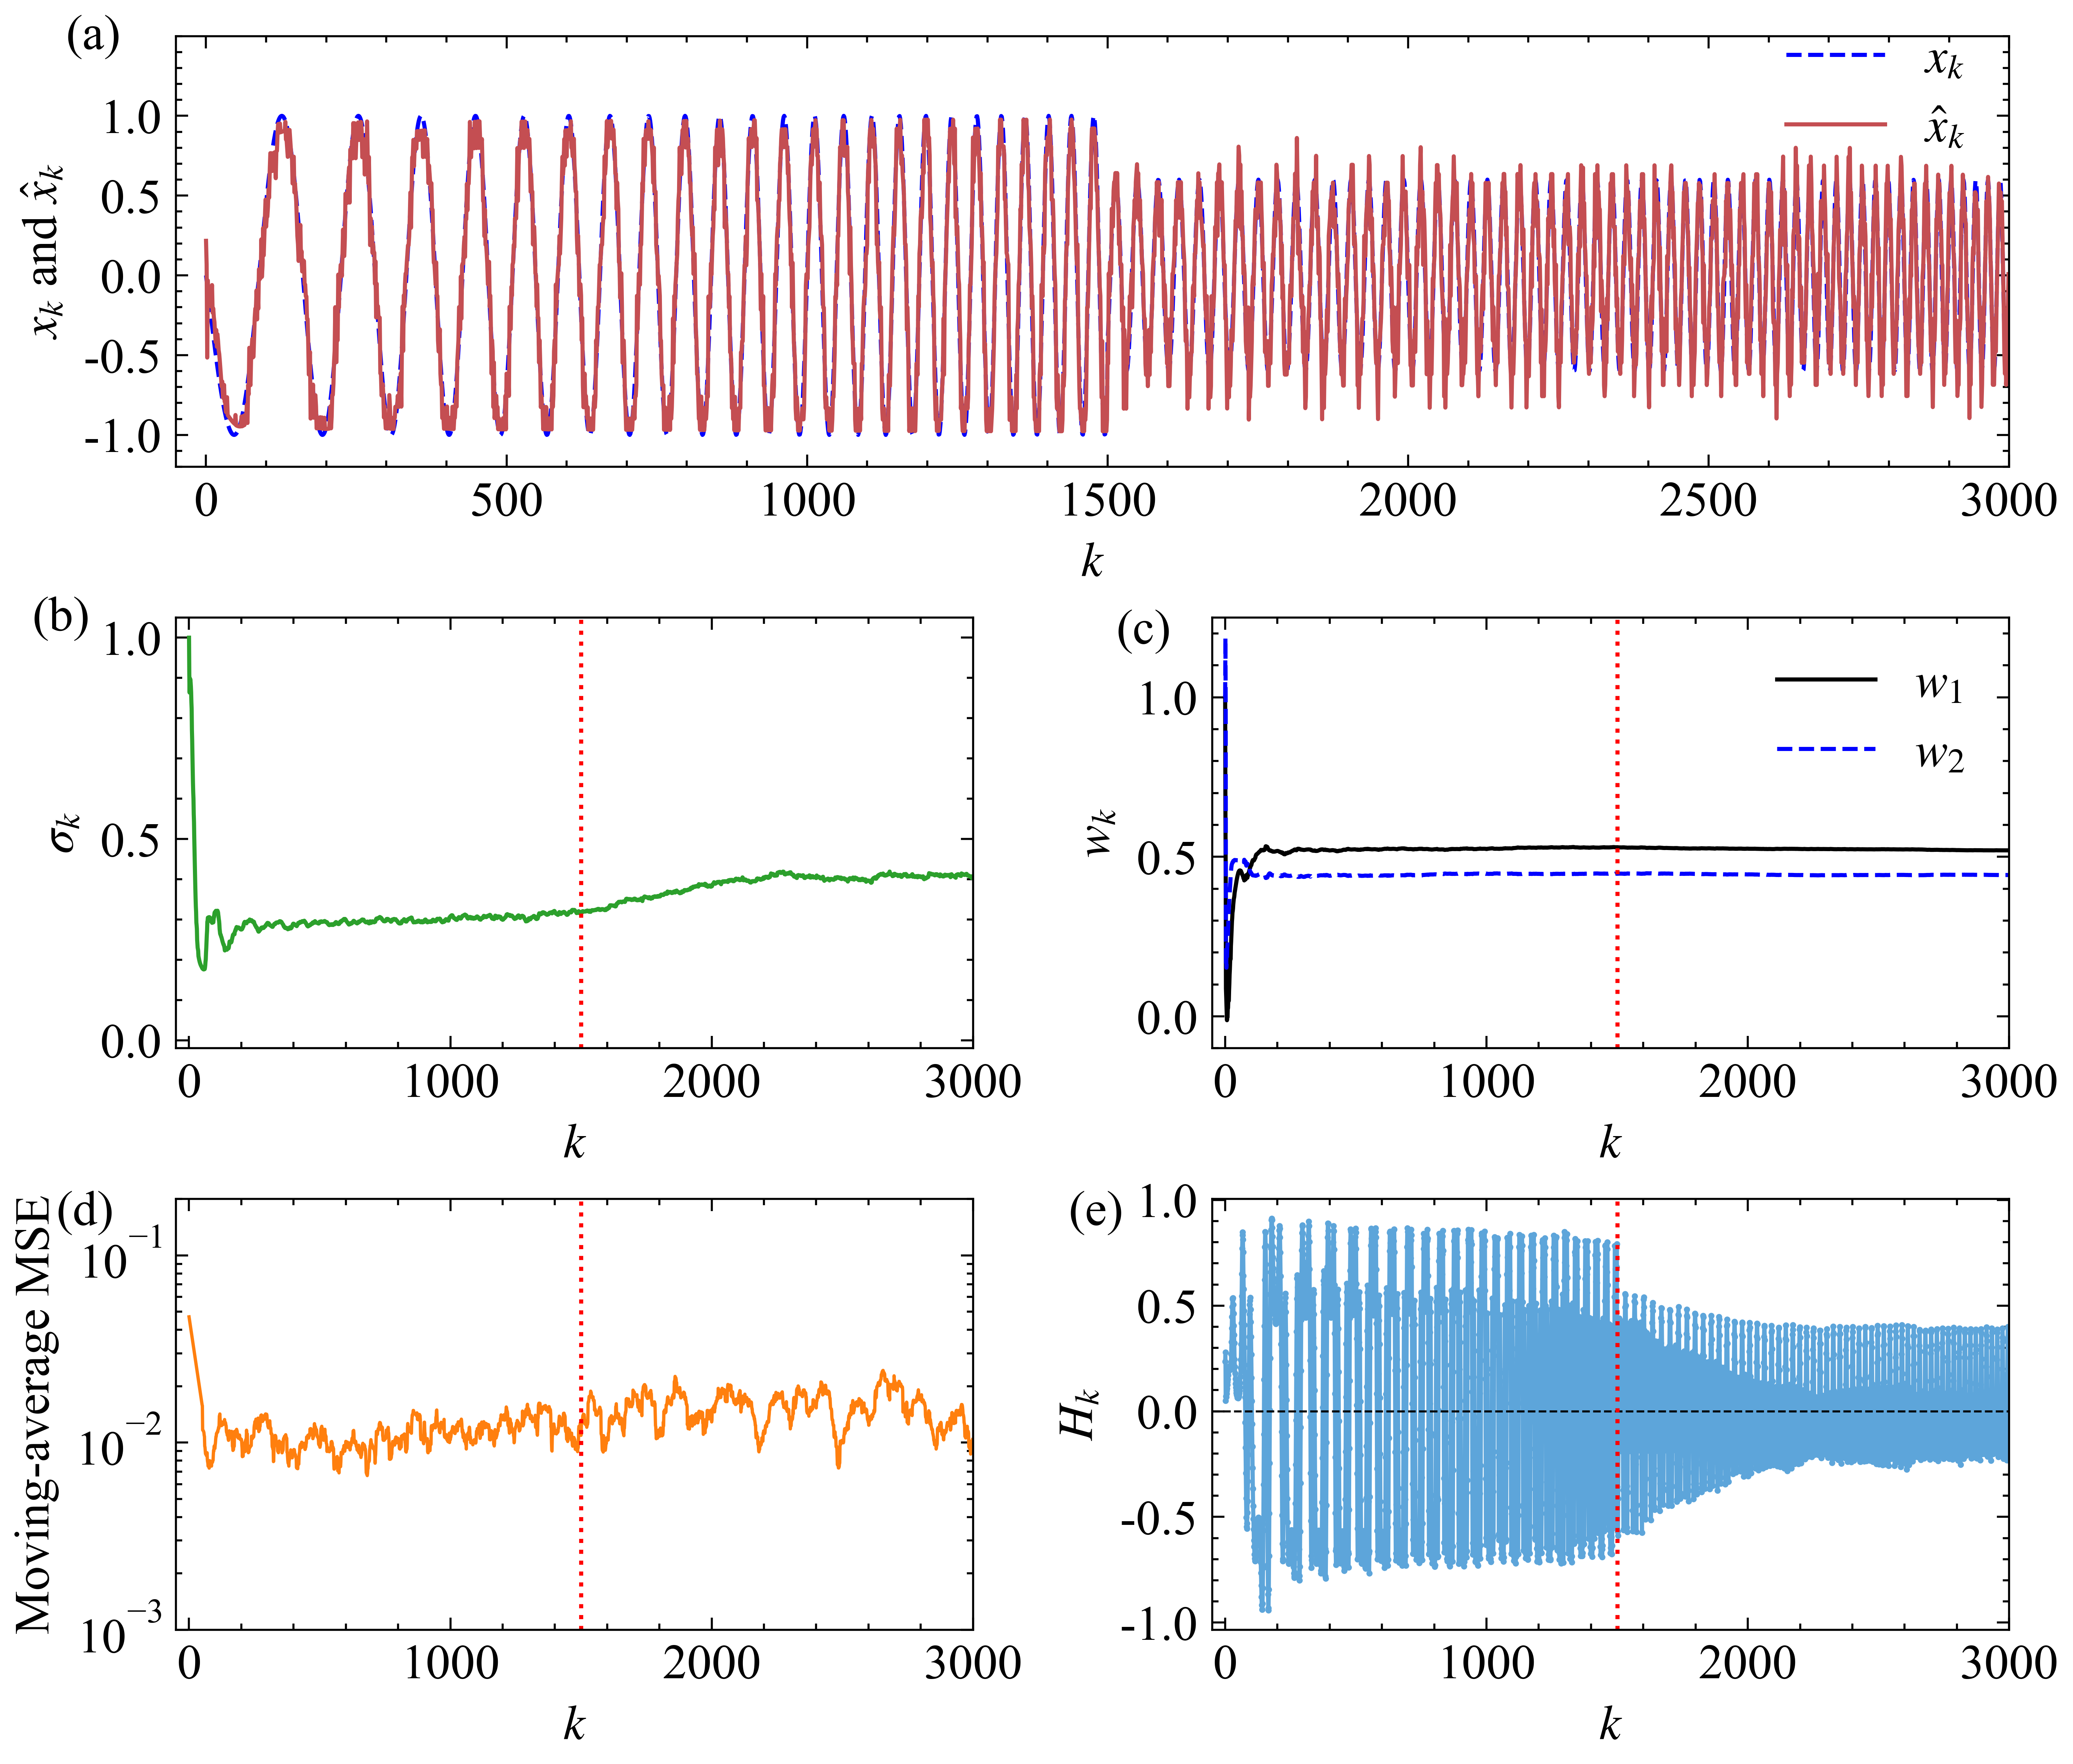

In [27]:
##### --- 绘图风格设置 ---
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import colorsys

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',   # 数学公式风格接近 Times
    'font.size': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
})

def lighten_color(color, amount=0.7):
    """
    Lightens the given color by mixing with white
    amount=0 returns white, amount=1 returns original color
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])
# 禁用 LaTeX 渲染
mpl.rcParams['text.usetex'] = False
mpl.rcParams['axes.unicode_minus'] = False


# ==========================================
# 创建多面板图：5个子图 - 带分段稳态标注
# ==========================================
fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.30)

axes = [
    fig.add_subplot(gs[0, :]),  # ax1: 信号跟踪
    fig.add_subplot(gs[1, 0]),  # ax2: σ收敛
    fig.add_subplot(gs[1, 1]),  # ax3: W收敛
    fig.add_subplot(gs[2, 0]),  # ax4: MSE性能
    fig.add_subplot(gs[2, 1]),  # ax5: 参数变化率
]

labels_txt = ['(a)', '(b)', '(c)', '(d)', '(e)']

# 从之前运行的结果获取数据
results = tracking_results['results']
metrics = tracking_results['metrics']
Nx_total = tracking_results['signal_params']['Nx_total']
transition_point = tracking_results['signal_params']['transition_point']

iterations = np.arange(Nx_total)

# 颜色方案
color_signal = '#1f77b4'
color_tracking = '#c44e52'

color_error = '#ff7f0e'
color_sigma = '#2ca02c'
color_W1 = '#9467bd'
color_W2 = '#8c564b'

# ==========================================
# Panel (a): 信号跟踪效果
# ==========================================
ax1 = axes[0]

ax1.plot(iterations, results['input_signal'], 
         color='b', linewidth=1.0, linestyle='--', label=r'$x_k$')
ax1.plot(iterations, results['y_hat_hist'], 
         color=color_tracking, linewidth=1.0, linestyle='-',
         label=r'$\hat{x}_k$')
ax1.legend(
    loc='upper right',
    bbox_to_anchor=(1.0, 1.1),  # y > 1 就是往上提
    fontsize=12
)
ax1.set_xlabel(r'$k$')
ax1.set_ylabel(r'$x_k$ and $\hat{x}_k$')
ax1.set_xlim(-50, Nx_total)
ax1.set_ylim(-1.2, 1.5)
ax1.set_yticks([-1, -0.5, 0, 0.5, 1])
ax1.text(-0.06, 1.05, labels_txt[0], transform=ax1.transAxes, fontsize=12, va='top')

# ==========================================
# Panel (b): σ 收敛曲线 - 带分段稳态标注
# ==========================================
ax2 = axes[1]

ax2.plot(iterations, results['sigma_hist'], 
         color=color_sigma, linewidth=1.0)

ax2.axvline(transition_point, color='red', linestyle=':', 
            linewidth=1.0)
ax2.set_xlabel(r'$k$')
ax2.set_ylabel(r'$\sigma_k$')
ax2.set_xlim(-50, Nx_total)
ax2.set_ylim(-0.02, 1.05)
ax2.text(-0.18, 1.05, labels_txt[1], transform=ax2.transAxes,
         fontsize=12, va='top')

# ==========================================
# Panel (c): W1 和 W2 收敛曲线 - 带分段稳态标注
# ==========================================
ax3 = axes[2]

W1_plot = np.concatenate(([1.0], results['W1_hist']))
W2_plot = np.concatenate(([1.0], results['W2_hist']))

# 迭代轴也要同步补一个点
iter_plot = np.arange(len(W1_plot))

ax3.plot(iter_plot, W1_plot,
         color='k', linewidth=1.0, linestyle='-', label=r'$w_1$')
ax3.plot(iter_plot, W2_plot,
         color='b', linewidth=1.0, linestyle='--', label=r'$w_2$')


ax3.axvline(transition_point, color='red', linestyle=':', 
            linewidth=1.0)


ax3.legend(loc='upper right', fontsize=12)
ax3.set_xlabel(r'$k$')
ax3.set_ylabel(r'$w_k$')
ax3.set_xlim(-50, Nx_total)
ax3.set_ylim(-0.1, 1.25)
ax3.text(-0.12, 1.02, labels_txt[2], transform=ax3.transAxes, fontsize=12, va='top')


# ==========================================
# Panel (d): 瞬时 MSE（对数坐标）
# ==========================================
ax4 = axes[3]
sq_error = results['error_hist'] ** 2
window = 50

# 对 sq_error(从第 2 个点开始) 做平滑
sq_error_smooth = np.convolve(
    sq_error[1:],
    np.ones(window) / window,
    mode='valid'
)

# 拼接：第一个原始点 + 平滑后的序列
sq_error_plot = np.concatenate((
    [sq_error[0]],
    sq_error_smooth
))

# 对应的 iteration
iter_plot = np.concatenate((
    [iterations[0]],
    iterations[1 + window - 1:]
))

# 一次性画
ax4.plot(iter_plot, sq_error_plot,
         color=color_error, linewidth=0.8)
ax4.axvline(transition_point, color='red', linestyle=':', 
            linewidth=1.0)
ax4.set_xlabel(r'$k$')
ax4.set_ylabel(r'Moving-average MSE',fontsize=12)
ax4.set_xlim(-50, Nx_total)
ax4.set_yscale('log')
ax4.set_ylim(1e-3, 0.2)  # 根据实际数据范围调整
ax4.text(-0.15, 1.02, labels_txt[3], transform=ax4.transAxes, fontsize=12, va='top')

# ==========================================
# Panel (e): Jacobian H_k 演化
# ==========================================
ax5 = axes[4]

ax5.plot(iterations, results['H_k_hist'], 
         marker='.', markersize=1.0, color='#5DA5DA')

ax5.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax5.axvline(transition_point, color='red', linestyle=':', 
            linewidth=1.0)
ax5.set_xlabel(r'$k$')
ax5.set_ylabel(r'$H_k$', fontsize=12)
ax5.set_xlim(-50, Nx_total)
ax5.set_yticks([-1, -0.5, 0, 0.5, 1])
ax5.text(-0.18, 1.02, labels_txt[4], transform=ax5.transAxes,
         fontsize=12, va='top')

plt.savefig('D:\IEEE 2025 Adaptive weighted SSR\Fig11.eps', format='eps', dpi=800)

plt.show()

In [ ]:
# # ==========================================
# # Panel (d): MSE 跟踪性能（分段稳态标注）
# # ==========================================
# ax4 = axes[3]

# # 绘制滑动窗口 MSE
# ax4.plot(iterations, results['mse_hist'], 
#          color=color_error, linewidth=1.0, label='Windowed MSE')

# # 填充区域
# ax4.fill_between(iterations, 0, results['mse_hist'],
#                  color=color_error, alpha=0.3)

# # 标注幅值变化点
# ax4.axvline(transition_point, color='red', linestyle=':', 
#             linewidth=1.5, alpha=0.7)

# # === 第一段 MSE 稳态值 ===
# mse1_mean = seg1['mse_mean']
# ax4.axhline(mse1_mean, 
#             xmin=seg1['start']/Nx_total, xmax=seg1['end']/Nx_total,
#             color='blue', linestyle='--', linewidth=1.5, alpha=0.8)

# ax4.text(seg1['start'] + (seg1['end']-seg1['start'])/2, 
#          mse1_mean * 1.8,  # 向上偏移
#          f"MSE_1 = {mse1_mean:.6f}",
#          ha='center', va='bottom', fontsize=9,
#          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
#                    edgecolor='blue', alpha=0.8))

# # === 第二段 MSE 稳态值 ===
# mse2_mean = seg2['mse_mean']
# ax4.axhline(mse2_mean, 
#             xmin=seg2['start']/Nx_total, xmax=seg2['end']/Nx_total,
#             color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.8)

# ax4.text(seg2['start'] + (seg2['end']-seg2['start'])/2, 
#          mse2_mean * 1.8,
#          f"MSE_2 = {mse2_mean:.6f}",
#          ha='center', va='bottom', fontsize=9,
#          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
#                    edgecolor='darkgreen', alpha=0.8))

# # 标注收敛点（相对于变化点）
# if metrics['convergence_time_segment2'] < (Nx_total - transition_point):
#     conv_time_abs = transition_point + metrics['convergence_time_segment2']
#     ax4.axvline(conv_time_abs, color='green', linestyle='--', 
#                 linewidth=1.0, alpha=0.7,
#                 label=f'Re-convergence: dk={metrics["convergence_time_segment2"]}')

# ax4.legend(loc='upper right', fontsize=9)
# ax4.set_xlabel('Sample k')
# ax4.set_ylabel('Mean Squared Error (MSE)')
# ax4.set_xlim(-50, Nx_total)
# ax4.set_yscale('log')
# ax4.grid(alpha=0.3, linestyle='--', linewidth=0.5)
# ax4.text(-0.12, 1.02, labels_txt[3], transform=ax4.transAxes,
#          fontsize=14, va='top', fontweight='bold')
# ==========================================
# Panel (e): 瞬时跟踪误差
# ==========================================
# ax5 = axes[4]

# # 绘制瞬时误差
# ax5.plot(iterations, results['error_hist'], 
#          color=color_error, linewidth=0.5, alpha=0.6,
#          label='Instantaneous Error e_k')

# # 绘制误差的移动平均
# window = 50
# error_smooth = np.convolve(results['error_hist'], 
#                            np.ones(window)/window, mode='same')
# ax5.plot(iterations, error_smooth, 
#          color='darkred', linewidth=1.5, alpha=0.9,
#          label=f'Smoothed Error (window={window})')

# # 标注零误差线
# ax5.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# # 标注幅值变化点
# ax5.axvline(transition_point, color='red', linestyle=':', 
#             linewidth=1.5, alpha=0.7, label='Amplitude Change')

# # 标注两段的误差均值
# seg1_error_mean = np.mean(results['error_hist'][seg1['start']:seg1['end']])
# seg2_error_mean = np.mean(results['error_hist'][seg2['start']:seg2['end']])

# ax5.axhline(seg1_error_mean, 
#             xmin=seg1['start']/Nx_total, xmax=seg1['end']/Nx_total,
#             color='blue', linestyle='--', linewidth=1.0, alpha=0.7)
# ax5.axhline(seg2_error_mean, 
#             xmin=seg2['start']/Nx_total, xmax=seg2['end']/Nx_total,
#             color='darkgreen', linestyle='--', linewidth=1.0, alpha=0.7)

# ax5.legend(loc='upper right', fontsize=9)
# ax5.set_xlabel('Sample k')
# ax5.set_ylabel('Tracking Error e_k')
# ax5.set_xlim(-50, Nx_total)
# ax5.set_ylim(-0.5, 0.5)  # 根据实际误差范围调整
# ax5.grid(alpha=0.3, linestyle='--', linewidth=0.5)
# ax5.text(-0.12, 1.02, labels_txt[4], transform=ax5.transAxes,
#          fontsize=14, va='top', fontweight='bold')

# # ==========================================
# # Panel (e): 信噪比（Signal-to-Noise Ratio）
# # ==========================================
# ax5 = axes[4]

# # 计算信噪比 SNR = 10 * log10(signal_power / noise_power)
# signal_power = results['input_signal']**2
# error_power = results['error_hist']**2
# snr = 10 * np.log10(signal_power / (error_power + 1e-10))

# # 平滑 SNR
# window = 100
# snr_smooth = np.convolve(snr, np.ones(window)/window, mode='same')

# ax5.plot(iterations, snr_smooth, 
#          color='#1f77b4', linewidth=1.2,
#          label='SNR (dB)')

# # 标注幅值变化点
# ax5.axvline(transition_point, color='red', linestyle=':', 
#             linewidth=1.5, alpha=0.7, label='Amplitude Change')

# # 标注两段的平均 SNR
# snr1_mean = np.mean(snr_smooth[seg1['start']:seg1['end']])
# snr2_mean = np.mean(snr_smooth[seg2['start']:seg2['end']])

# ax5.axhline(snr1_mean, 
#             xmin=seg1['start']/Nx_total, xmax=seg1['end']/Nx_total,
#             color='blue', linestyle='--', linewidth=1.5, alpha=0.8)
# ax5.axhline(snr2_mean, 
#             xmin=seg2['start']/Nx_total, xmax=seg2['end']/Nx_total,
#             color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.8)

# ax5.text(seg1['start'] + (seg1['end']-seg1['start'])/2, 
#          snr1_mean + 2,
#          f"SNR_1 = {snr1_mean:.1f} dB",
#          ha='center', va='bottom', fontsize=9,
#          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
#                    edgecolor='blue', alpha=0.8))

# ax5.text(seg2['start'] + (seg2['end']-seg2['start'])/2, 
#          snr2_mean + 2,
#          f"SNR_2 = {snr2_mean:.1f} dB",
#          ha='center', va='bottom', fontsize=9,
#          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
#                    edgecolor='darkgreen', alpha=0.8))

# ax5.legend(loc='lower right', fontsize=9)
# ax5.set_xlabel('Sample k')
# ax5.set_ylabel('Signal-to-Noise Ratio (dB)')
# ax5.set_xlim(-50, Nx_total)
# ax5.grid(alpha=0.3, linestyle='--', linewidth=0.5)
# ax5.text(-0.12, 1.02, labels_txt[4], transform=ax5.transAxes,
#          fontsize=14, va='top', fontweight='bold')
# # ==========================================
# 添加总标题
# ==========================================